In [1]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:

df = pd.read_csv("cereal.csv")

In [4]:

# Select Numerical Columns Only

numeric_df = df.select_dtypes(include=['float64', 'int64'])

In [5]:
numeric_df

,Calories,Protein (g),Fat,Sugars,Vitamins and Minerals
0,70,4,1,6,25
1,120,3,5,8,0
2,70,4,1,5,25
3,50,4,0,0,25
4,110,2,2,8,25
...,...,...,...,...,...
69,110,2,1,3,25
70,110,1,1,12,25
71,100,3,1,3,25
72,100,3,1,3,25


In [6]:

# Scale Numerical Data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


In [7]:

#  Apply KMeans Clustering

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)


  File "C:\Users\nvgra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nvgra\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [8]:

df["Cluster"] = clusters

print("✔ Clustering Completed")
print(df.head())


✔ Clustering Completed
                 Cereal Name    Manufacturer  Calories  Protein (g)  Fat  \
0                  100%_Bran         Nabisco        70            4    1   
1          100%_Natural_Bran     Quaker Oats       120            3    5   
2                   All-Bran        Kelloggs        70            4    1   
3  All-Bran_with_Extra_Fiber        Kelloggs        50            4    0   
4             Almond_Delight  Ralston Purina       110            2    2   

   Sugars  Vitamins and Minerals  Cluster  
0       6                     25        2  
1       8                      0        1  
2       5                     25        2  
3       0                     25        2  
4       8                     25        0  


In [9]:

#  Cluster Summary

cluster_summary = df.groupby("Cluster")[numeric_df.columns].mean()
print("\nCluster Summary (Mean Values):")
print(cluster_summary)



Cluster Summary (Mean Values):
           Calories  Protein (g)       Fat     Sugars  Vitamins and Minerals
Cluster                                                                     
0        115.806452     1.903226  1.064516  11.032258              34.677419
1        111.538462     3.846154  2.076923   5.153846              21.153846
2         92.333333     2.533333  0.333333   3.066667              25.000000


In [10]:
# Elbow Method (Find Best k)

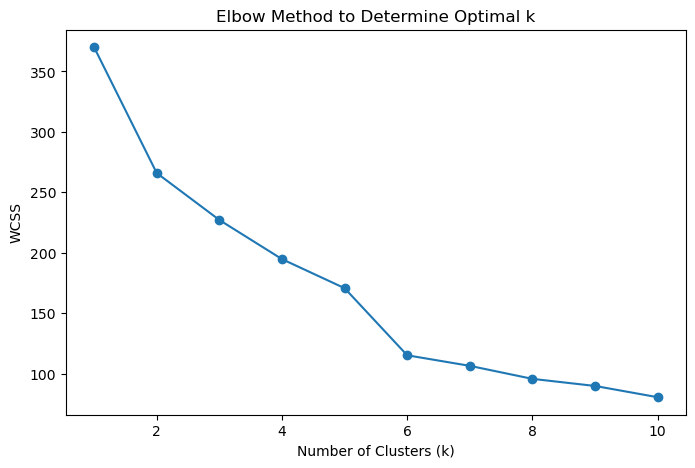

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []  # Within-cluster sum of squares

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method to Determine Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()


In [12]:
# Silhouette Score (Cluster Quality)

In [13]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"k = {k}, Silhouette Score = {score:.4f}")


k = 2, Silhouette Score = 0.2740
k = 3, Silhouette Score = 0.2582
k = 4, Silhouette Score = 0.2608
k = 5, Silhouette Score = 0.2698
k = 6, Silhouette Score = 0.3378
k = 7, Silhouette Score = 0.3405
k = 8, Silhouette Score = 0.2874
k = 9, Silhouette Score = 0.3000


In [14]:
# Save Output With Cluster Labels

In [15]:
df.to_csv("cereal_clustered.csv", index=False)
print("File saved as cereal_clustered.csv")


File saved as cereal_clustered.csv


In [16]:
# Visualize Clusters With PCA

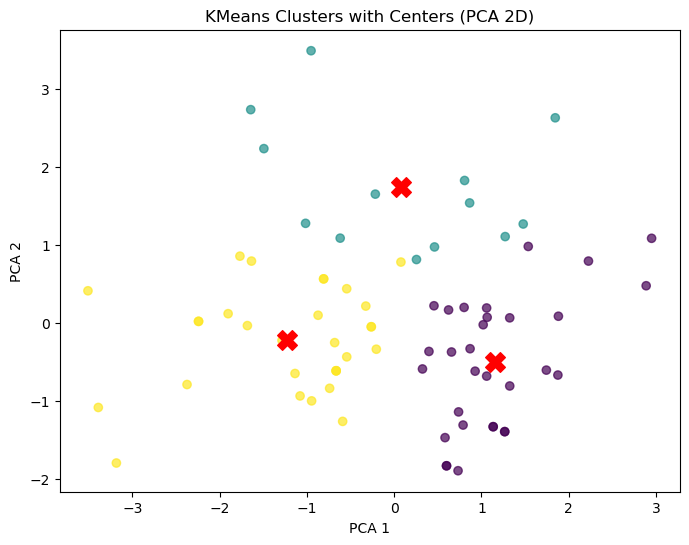

In [17]:
import numpy as np

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df["Cluster"], alpha=0.7)
plt.scatter(centers_2d[:,0], centers_2d[:,1], s=200, c='red', marker='X')
plt.title("KMeans Clusters with Centers (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [18]:
# Cluster Interpretation 

In [20]:
summary = df.groupby("Cluster")[numeric_df.columns].mean()

summary

,Calories,Protein (g),Fat,Sugars,Vitamins and Minerals
Cluster,,,,,
0,115.806452,1.903226,1.064516,11.032258,34.677419
1,111.538462,3.846154,2.076923,5.153846,21.153846
2,92.333333,2.533333,0.333333,3.066667,25.000000


In [ ]:
for cluster_id in summary.index:
    print(f"\nCluster {cluster_id} Characteristics:")
    for col in summary.columns:
        print(f" - {col}: {summary.loc[cluster_id, col]:.2f}")


| Cluster | Meaning                       | Why                                                       |
| ------- | ----------------------------- | --------------------------------------------------------- |
| **0**   | **Sugary cereals**            | High sugar, low protein, heavily fortified                |
| **1**   | **Balanced cereals**          | Good protein, moderate sugar, higher fat, more nutritious |
| **2**   | **Diet / high-fiber cereals** | Low calories, low sugar, very low fat                     |


Cluster 0 — High-Sugar, Low-Protein Cereals (Sugary Cereals)

Characteristics:

    *  High sugars (11.03) → This is the highest among all clusters.
        
    *  Low protein (1.90)
        
    *  Moderate calories (115.81)
        
    *  Low fat (1.06)

    * Highest vitamins/minerals (34.68) → Often because sugary cereals are artificially fortified.

    These are likely children-targeted cereals, sweetened, palatable, and fortified to look “healthy.”

Examples: Fruit Loops, Frosted Flakes, Cocoa cereals, etc.


Cluster 1 — Balanced / Moderate Cereals (Healthy Balanced Cereals)

Characteristics:

    * Moderate sugars (5.15)
    
    * Highest protein (3.85)
    
    * Higher fat (2.08)
    
    * Higher calories (111.54)
    
    * Lowest vitamins/minerals (21.15)


    These cereals are typically moderately sweet, more whole-grain, and more filling.
    
    They provide better protein and fat balance—good for adults or health-focused consumers.

Examples: Oat-based cereals, granolas (without too much sugar), whole wheat cereals.


Cluster 2 — Low-Calorie, Low-Sugar Cereals (Diet / High-Fiber Cereals)

Characteristics:

   * Lowest calories (92.33)
    
   *  Low sugar (3.07)
    
   * Very low fat (0.33)
    
    * Moderate protein (2.53)
    
    * Moderate vitamins/minerals
    
    * VERY low fat indicates diet or high-fiber cereals


    These are diet, fiber-rich, low-calorie cereals.
    Best for people focused on weight loss or diabetics who avoid sugar.

Examples: Bran cereals, fiber-rich flakes, puffed rice.